In [1]:
import os
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define paths
project_path = '/content/drive/MyDrive/mes_project/Complex-YOLOv4-Pytorch'
dataset_path = '/content/drive/MyDrive/mes_project/KITTI_AUG'

print('--- Project Directory Content ---')
!ls -F {project_path}

print('\n--- Dataset Directory Content ---')
!ls -F {dataset_path}

# Look for requirements.txt or setup files
if os.path.exists(f'{project_path}/requirements.txt'):
    print('\n--- Requirements file found ---')
else:
    print('\n--- No requirements.txt found in project root ---')

--- Project Directory Content ---
checkpoints/  docs/    logs/	  requirements.txt
dataset/      LICENSE  README.md  src/

--- Dataset Directory Content ---
/content/drive/MyDrive/mes_project/KITTI_AUG@

--- Requirements file found ---


In [2]:
pip install torch torchvision easydict opencv-python numpy torchsummary tensorboard scikit-learn shapely

In [ ]:
import os
project_path = "/content/drive/MyDrive/mes_project/Complex-YOLOv4-Pytorch"
dataset_path = "/content/drive/MyDrive/mes_project/KITTI_AUG"
os.chdir(os.path.join(project_path, "src"))

# Running with batch size 4, 40 epochs
!python train.py --saved_fn complex_yolov4_kitti_aug --arch darknet --cfgfile ./config/cfg/complex_yolov4.cfg --batch_size 4 --num_workers 4 --gpu_idx 0 --num_epochs 40 --checkpoint_freq 5 --dataset_dir {dataset_path}

2026-03-27 19:20:38.176924: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774639238.198186   26373 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774639238.205312   26373 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774639238.223688   26373 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774639238.223733   26373 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774639238.223738   26373 computation_placer.cc:177] computation placer alr

In [61]:
import os
project_path = "/content/drive/MyDrive/mes_project/Complex-YOLOv4-Pytorch"
dataset_path = "/content/drive/MyDrive/mes_project/KITTI_AUG"
os.chdir(os.path.join(project_path, "src"))

# Try lower confidence (0.1) and iou (0.3) to see if model is producing any valid boxes at all
!python evaluate.py --arch darknet \
    --cfgfile ./config/cfg/complex_yolov4.cfg \
    --pretrained_path ../checkpoints/complex_yolov4_kitti_aug/Model_complex_yolov4_kitti_aug_epoch_40.pth \
    --batch_size 4 \
    --num_workers 4 \
    --gpu_idx 0 \
    --conf-thresh 0.1 \
    --nms-thresh 0.5 \
    --iou-thresh 0.3 \
    --dataset_dir {dataset_path}

Using darknet backbone
[INFO] No error, the convolution haven't activate linear
[INFO] No error, the convolution haven't activate linear
[INFO] No error, the convolution haven't activate linear


-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=


Create the validation dataloader
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '7'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '5'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '3'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '4'
DEBUG: Received cl

### Standard KITTI Label Format
Each line in the label `.txt` file represents one object with 15 values:

| Value | Name | Description |
| :--- | :--- | :--- |
| 1 | `type` | Describes the object (e.g., 'Car', 'Tractor', 'Pedestrian') |
| 2 | `truncated` | Float from 0 (non-truncated) to 1 (truncated) |
| 3 | `occluded` | Integer (0=fully visible, 1=partly occluded, 2=largely occluded, 3=unknown) |
| 4 | `alpha` | Observation angle of object, ranging [-pi..pi] |
| 5-8 | `bbox` | 2D bounding box of object in the image (0-based index): contains left, top, right, bottom pixel coordinates |
| 9-11 | `dimensions` | 3D object dimensions: height, width, length (in meters) |
| 12-14 | `location` | 3D object location x,y,z in camera coordinates (in meters) |
| 15 | `rotation_y` | Rotation ry around Y-axis in camera coordinates [-pi..pi] |

**Example Label:**
`Car 0.00 0 1.85 387.63 181.54 423.53 203.12 1.67 1.87 3.69 -1.65 2.39 13.50 1.55`

---

### KITTI Calibration Format
Calibration files (usually `calib.txt`) map points from LiDAR space to Camera space. Complex-YOLOv4 specifically uses:
1.  **Tr_velo_to_cam**: 3x4 Matrix to project LiDAR points to the Camera coordinate system.
2.  **R0_rect**: 3x3 Rectification matrix to correct the stereo camera image.
3.  **P2**: 3x4 Projection matrix for the color camera.

**Example Calibration entries:**
```
P2: 7.21e+02 0.00e+00 6.09e+02 4.48e+01 0.00e+00 7.21e+02 1.72e+02 2.16e-01 0.00e+00 0.00e+00 1.00e+00 2.74e-03
R0_rect: 9.99e-01 9.77e-03 -1.01e-02 -9.84e-03 9.99e-01 -6.51e-03 1.01e-02 6.61e-03 9.99e-01
Tr_velo_to_cam: 7.53e-03 -9.99e-01 -3.67e-04 -4.06e-03 1.48e-04 7.24e-04 -9.99e-01 -7.63e-02 9.99e-01 7.53e-03 1.48e-04 -2.71e-01
```

In [55]:
import numpy as np

def check_bev_mapping(x, y, z):
    # Complex-YOLOv4 standard BEV range:
    # x: [-40, 40], z: [0, 70.4]
    # Based on your labels (Location X, Y, Z in fields 12, 13, 14)
    bev_x = x
    bev_z = z

    is_in_view = (-40 < bev_x < 40) and (0 < bev_z < 70.4)
    return bev_x, bev_z, is_in_view

# Sample from your first line: 6 0 0 0 ... -12.05 97.23 30.80
sample_x, sample_y, sample_z = -12.05, 97.23, 30.80
x_proj, z_proj, valid = check_bev_mapping(sample_x, sample_y, sample_z)

print(f'Object at ({sample_x}, {sample_y}, {sample_z})')
print(f'Projected BEV Coord: ({x_proj}, {z_proj})')
print(f'Inside model view: {valid}')

Object at (-12.05, 97.23, 30.8)
Projected BEV Coord: (-12.05, 30.8)
Inside model view: True


In [58]:
import os
project_path = "/content/drive/MyDrive/mes_project/Complex-YOLOv4-Pytorch"
dataset_path = "/content/drive/MyDrive/mes_project/KITTI_AUG"
os.chdir(os.path.join(project_path, "src"))

# Re-running evaluation. Note: the dataset loader in kitti_dataset.py
# already points to 'label_2_id' based on our previous analysis.
!python evaluate.py --arch darknet \
    --cfgfile ./config/cfg/complex_yolov4.cfg \
    --pretrained_path ../checkpoints/complex_yolov4_kitti_aug/Model_complex_yolov4_kitti_aug_epoch_40.pth \
    --batch_size 4 \
    --num_workers 4 \
    --gpu_idx 0 \
    --conf-thresh 0.5 \
    --nms-thresh 0.5 \
    --iou-thresh 0.5 \
    --dataset_dir {dataset_path}

Using darknet backbone
[INFO] No error, the convolution haven't activate linear
[INFO] No error, the convolution haven't activate linear
[INFO] No error, the convolution haven't activate linear


-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=-*=


Create the validation dataloader
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '7'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '4'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '5'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '3'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '2'
DEBUG: Received cls_type: '4'
DEBUG: Received cl

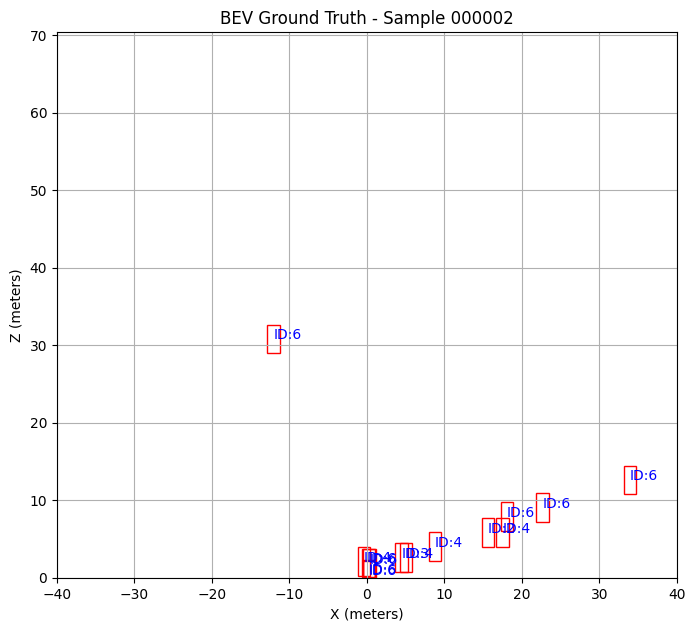

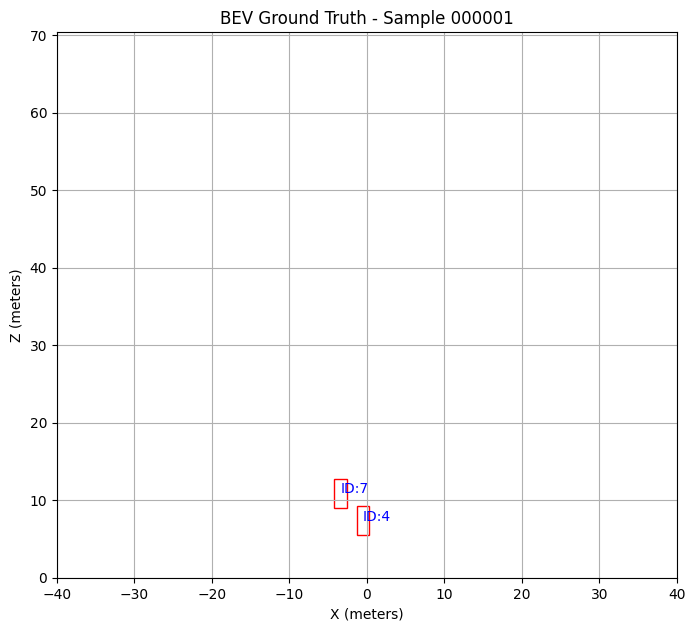

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_bev(sample_id, dataset_path):
    # Load Labels
    label_path = os.path.join(dataset_path, 'training/label_2_id', f'{sample_id}.txt')
    if not os.path.exists(label_path):
        print(f'Label not found for {sample_id}')
        return

    # BEV Settings (Complex-YOLO standard)
    # Range: x: [-40, 40], z: [0, 70.4]
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.set_xlim(-40, 40)
    ax.set_ylim(0, 70.4)
    ax.set_aspect('equal')
    ax.set_title(f'BEV Ground Truth - Sample {sample_id}')
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Z (meters)')

    with open(label_path, 'r') as f:
        for line in f:
            data = line.split()
            cls_id = data[0]
            # KITTI Label fields 11, 12, 13 are Loc X, Y, Z
            x, z = float(data[11]), float(data[13])
            # Fields 8, 9, 10 are H, W, L
            w, l = float(data[9]), float(data[10])
            ry = float(data[14])

            # Draw Box
            rect = plt.Rectangle((x - w/2, z - l/2), w, l, angle=np.degrees(-ry), color='red', fill=False, label='GT')
            ax.add_patch(rect)
            ax.text(x, z, f'ID:{cls_id}', color='blue', fontsize=10)

    plt.grid(True)
    plt.show()

# Visualize a few samples from your data
dataset_path = '/content/drive/MyDrive/mes_project/KITTI_AUG'
plot_bev('000002', dataset_path)
plot_bev('000001', dataset_path)

In [59]:
import os
import random

dataset_path = '/content/drive/MyDrive/mes_project/KITTI_AUG/training'
folders = {
    'images': 'image_2',
    'labels_orig': 'label_2',
    'labels_id': 'label_2_id',
    'calib_orig': 'calib',
    'calib_padded': 'calib_padded'
}

# Get all available image IDs
image_dir = os.path.join(dataset_path, folders['images'])
if os.path.exists(image_dir):
    all_ids = [f.split('.')[0] for f in os.listdir(image_dir) if f.endswith('.png') or f.endswith('.jpg')]
    sample_ids = random.sample(all_ids, min(2, len(all_ids)))

    for sample_id in sample_ids:
        print(f'\n' + '='*50)
        print(f'CHECKING SAMPLE ID: {sample_id}')
        print('='*50)

        for key, folder_name in folders.items():
            if key == 'images': continue

            ext = '.txt'
            file_path = os.path.join(dataset_path, folder_name, f'{sample_id}{ext}')

            print(f'\n--- Folder: {folder_name} ---')
            if os.path.exists(file_path):
                with open(file_path, 'r') as f:
                    content = f.read().strip()
                    # Print first 2 lines for labels, full content for calib
                    if 'label' in key:
                        lines = content.split('\n')
                        print('\n'.join(lines[:2]))
                        if len(lines) > 2: print('...')
                    else:
                        print(content)
            else:
                print(f'FILE NOT FOUND: {file_path}')
else:
    print(f'Directory not found: {image_dir}')


CHECKING SAMPLE ID: 001620

--- Folder: label_2 ---
Bicycle 0 0 0 1070.00 464.00 1394.00 636.00 1.50 1.60 3.70 13.31 4.27 15.73 0.00
Car 0 0 0 133.00 427.00 309.00 789.00 1.50 1.60 3.70 -16.07 9.51 26.85 0.00
...

--- Folder: label_2_id ---
2 0 0 0 1070.00 464.00 1394.00 636.00 1.50 1.60 3.70 13.31 4.27 15.73 0.00
4 0 0 0 133.00 427.00 309.00 789.00 1.50 1.60 3.70 -16.07 9.51 26.85 0.00
...

--- Folder: calib ---
P2: 700.0 0 1536.0 0 0 700.0 2040.0 0 0 0 1 0
R0_rect: 1 0 0 0 1 0 0 0 1
Tr_velo_to_cam: 1 0 0 0 0 1 0 0 0 0 1 0

--- Folder: calib_padded ---
P0: 0 0 0 0 0 0 0 0 0 0 0 0
P1: 0 0 0 0 0 0 0 0 0 0 0 0
P2: 700.0 0 1536.0 0 0 700.0 2040.0 0 0 0 1 0
P3: 0 0 0 0 0 0 0 0 0 0 0 0
R0_rect: 1 0 0 0 1 0 0 0 1
Tr_velo_to_cam: 1 0 0 0 0 1 0 0 0 0 1 0
Tr_imu_to_velo: 1 0 0 0 0 1 0 0 0 0 1 0

CHECKING SAMPLE ID: 002872

--- Folder: label_2 ---
Bicycle 0 0 0 1290.00 647.00 1576.00 826.00 1.50 1.60 3.70 16.70 7.93 14.74 0.00
Bicycle 0 0 0 1031.00 482.00 1135.00 582.00 1.50 1.60 3.70 6.38 2.48